In [1]:
import pandas as pd
import numpy as np
import datetime

import yfinance as yf

from saber import metaLib as mtlib

#PA = pa.PA(login = "7933713",pw = '1523@Rocket')
from saber import PyFolio as pf
from saber import utilities as ut
from saber import mailer as mail

from saber import metaData as mtd
from saber import riskEngine as risk
from saber import PcEngine as pe
from saber import implementationEngine as ie
from saber import PyFolio as pyf
from saber import PerformanceAnalytics as pa
import os
    

%load_ext autoreload
%autoreload 2

#mtw = mtlib.meta5_wrapper()

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
mtw = mtlib.meta5_wrapper(login = 7933713,pw = '1523@Rocket')
PerfA = pa.PA(mtw)
rkm = risk.riskMgr(mtw)

In [3]:
start = datetime.datetime.now() - datetime.timedelta(days=1)   # just pull last 24–48h
end = datetime.datetime.now() + datetime.timedelta(days=10)

In [4]:
def update_realized_pnl(PerfA, directory):
    import os
    
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    filename = f"dgm_realized_pnl_{today}.csv"
    filepath = os.path.join(directory, filename)
    
    df = PerfA.get_realized_pnl_by_date(datetime.datetime.today())
    df.to_csv(filepath, index_label='Date')
    print(f"Saved: {filename}")
    return df

In [5]:
def update_realized_pnl(PerfA, directory):
    import os
    
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    filename = f"dgm_realized_pnl_{today}.csv"
    filepath = os.path.join(directory, filename)
    
    df = PerfA.get_realized_pnl_by_date(datetime.datetime.today())
    
    if df.empty or df.drop(columns='TOTAL', errors='ignore').sum().sum() == 0:
        print(f"No realized trades today - skipping save")
        return
    
    df.to_csv(filepath, index_label='Date')
    print(f"Saved: {filename}")
    return df

In [6]:
update_realized_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")

Saved: dgm_realized_pnl_2026-03-10.csv


,AUDJPY,AUDNZD,AUDUSD,BP.LSE,BTCUSD,ETHUSD,EURAUD,EURUSD,GBPUSD,JGB10Y_H6,...,UST30Y_H6,USTEC,VIX_G6,VIX_H6,XAGUSD,XAUUSD,XBRUSD,XOM.NYSE-24,XTIUSD,TOTAL
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-10,0.0,0.0,0.0,0.0,0.0,0.0,-418.41,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-418.41


In [7]:
update_floating_pnl(PerfA,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")

NameError: name 'update_floating_pnl' is not defined

In [ ]:
def update_portfolio_var(rkm, directory):
    import os
    
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    filename = f"dgm_portfolio_var_{today}.csv"
    filepath = os.path.join(directory, filename)
    
    var = rkm.get_portfolio_var()
    
    # Wrap in dataframe with today's date if not already a dataframe
    if not isinstance(var, pd.DataFrame):
        df = pd.DataFrame({'VaR': [var]}, index=[today])
        df.index.name = 'Date'
    else:
        df = var.copy()
        df.index = [today]
        df.index.name = 'Date'
    
    if df.empty:
        print(f"No VaR data - skipping save")
        return
    
    df.to_csv(filepath, index_label='Date')
    print(f"Saved: {filename}")
    return df

In [ ]:
update_portfolio_var(rkm,r"C:\Users\kmavy\Documents\mydocs\My Docs\Investments\investments-app\discretionary_macro")

Saved: dgm_portfolio_var_2026-02-03.csv


,VaR
Date,
2026-02-03,-2240.615385


In [ ]:
update_mtm_pnl(csv_path='dgm_mtm_pnl.csv')

MTM PnL: Created new file with 101 dates
Floating PnL: Today already exists


(symbol      XBRUSD  FIVE.NAS  MNDY.NAS  STOXX50   XAUUSD  USDMXN  USDJPY  \
 2025-09-23  -49.15      0.00      0.00     0.00     2.69    0.00    0.00   
 2025-09-24  -51.72      0.00      0.00     0.00    33.69    0.00    0.00   
 2025-09-25  -75.57      0.00      0.00     0.00    33.69    0.00    0.00   
 2025-09-26  -75.57      0.00      0.00     0.00    33.69    0.00    0.00   
 2025-09-27  -75.57      0.00      0.00     0.00    33.69    0.00    0.00   
 ...            ...       ...       ...      ...      ...     ...     ...   
 2026-01-28 -212.94     -0.51    160.56   301.66  2597.95 -269.53 -691.31   
 2026-01-29 -212.94     -0.51    160.56   301.66  3636.04 -269.53 -737.23   
 2026-01-30 -212.94     -0.51    160.56   301.66  3584.90 -269.53 -952.85   
 2026-01-31 -212.94     -0.51    160.56   301.66  2562.20 -269.53 -860.00   
 2026-02-02 -212.94   -113.19   1384.82   301.66  2472.92 -207.02 -703.41   
 
 symbol      MKSI.NAS  PLTR.NAS  CHINA50  ...  AUDJPY  INTC.NAS  EURUSD  \

In [ ]:
def update_mtm_pnl(csv_path='mtm_pnl.csv', floating_csv_path='floating_pnl.csv'):
    """
    Updates CSVs with cumulative mark-to-market PnL and daily floating PnL snapshot
    1. Fills in any missing historical dates from realized PnL
    2. Adds today's MTM (realized + floating)
    Existing dates are NEVER overwritten
    """
    import os
    
    # Get today's date
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    
    # Get realized daily PnL (daily change) and cumulate it
    realized_pnl = PA.get_daily_pnl()
    realized_cumulative = realized_pnl.drop(columns='TOTAL', errors='ignore').cumsum()
    
    # Get floating PnL (already cumulative, point-in-time)
    floating_pnl = PA.get_acc_floating_pnl().drop(columns='TOTAL', errors='ignore')
    
    # Align columns
    all_symbols = list(set(realized_cumulative.columns.tolist() + floating_pnl.columns.tolist()))
    realized_cumulative = realized_cumulative.reindex(columns=all_symbols, fill_value=0)
    floating_pnl = floating_pnl.reindex(columns=all_symbols, fill_value=0)
    
    # Standardize realized_cumulative index
    realized_cumulative.index = [str(d) for d in realized_cumulative.index]
    
    # Build today's MTM = cumulative realized + current floating
    if today in realized_cumulative.index:
        today_mtm = realized_cumulative.loc[[today]] + floating_pnl.values
    else:
        if len(realized_cumulative) > 0:
            last_realized = realized_cumulative.iloc[[-1]].copy()
            last_realized.index = [today]
            today_mtm = last_realized + floating_pnl.values
        else:
            today_mtm = floating_pnl.copy()
    
    # Build full new dataset: past realized + today's MTM
    past_realized = realized_cumulative[realized_cumulative.index < today]
    full_dataset = pd.concat([past_realized, today_mtm])
    full_dataset['TOTAL'] = full_dataset.sum(axis=1)
    
    # --- Save MTM PnL CSV ---
    if os.path.exists(csv_path):
        existing_mtm = pd.read_csv(csv_path, index_col='Date')
        existing_mtm.index = pd.to_datetime(existing_mtm.index, format='mixed', dayfirst=True).strftime('%Y-%m-%d')
        
        # Find missing dates (in full dataset but not in existing CSV)
        missing_dates = [d for d in full_dataset.index if d not in existing_mtm.index]
        
        if len(missing_dates) > 0:
            missing_data = full_dataset.loc[missing_dates]
            
            # Align columns
            all_cols = list(set(existing_mtm.columns.tolist() + missing_data.columns.tolist()))
            all_cols = [c for c in all_cols if c != 'TOTAL']
            existing_mtm = existing_mtm.drop(columns='TOTAL', errors='ignore').reindex(columns=all_cols, fill_value=0)
            missing_data = missing_data.drop(columns='TOTAL', errors='ignore').reindex(columns=all_cols, fill_value=0)
            
            existing_mtm = pd.concat([existing_mtm, missing_data])
            existing_mtm['TOTAL'] = existing_mtm.sum(axis=1)
            print(f"MTM PnL: Added {len(missing_dates)} missing dates: {missing_dates}")
        else:
            print("MTM PnL: No missing dates")
        
        existing_mtm.sort_index(inplace=True)
        existing_mtm.to_csv(csv_path, index_label='Date')
    else:
        existing_mtm = full_dataset.copy()
        existing_mtm.sort_index(inplace=True)
        existing_mtm.to_csv(csv_path, index_label='Date')
        print(f"MTM PnL: Created new file with {len(existing_mtm)} dates")
    
    # --- Save Floating PnL CSV ---
    floating_snapshot = floating_pnl.copy()
    floating_snapshot.index = [today]
    floating_snapshot['TOTAL'] = floating_snapshot.sum(axis=1)
    
    if os.path.exists(floating_csv_path):
        existing_floating = pd.read_csv(floating_csv_path, index_col='Date')
        existing_floating.index = pd.to_datetime(existing_floating.index, format='mixed', dayfirst=True).strftime('%Y-%m-%d')
        
        if today not in existing_floating.index:
            all_cols = list(set(existing_floating.columns.tolist() + floating_snapshot.columns.tolist()))
            all_cols = [c for c in all_cols if c != 'TOTAL']
            existing_floating = existing_floating.drop(columns='TOTAL', errors='ignore').reindex(columns=all_cols, fill_value=0)
            floating_snapshot = floating_snapshot.drop(columns='TOTAL', errors='ignore').reindex(columns=all_cols, fill_value=0)
            
            existing_floating = pd.concat([existing_floating, floating_snapshot])
            existing_floating['TOTAL'] = existing_floating.sum(axis=1)
            print(f"Floating PnL: Added {today}")
        else:
            print("Floating PnL: Today already exists")
        
        existing_floating.sort_index(inplace=True)
        existing_floating.to_csv(floating_csv_path, index_label='Date')
    else:
        existing_floating = floating_snapshot.copy()
        existing_floating.to_csv(floating_csv_path, index_label='Date')
        print(f"Floating PnL: Created new file")
    
    return existing_mtm, existing_floating


In [182]:
pnl = pd.read_csv("mtm_pnl.csv", index_col='Date',parse_dates = True)
pnl

,XBRUSD,FIVE.NAS,MNDY.NAS,STOXX50,XAUUSD,USDMXN,USDJPY,MKSI.NAS,PLTR.NAS,CHINA50,...,AUDJPY,INTC.NAS,EURUSD,USTEC,BTCUSD,LITE.NAS,US500,AUS200,SCCO.NYSE,TOTAL
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-23,-49.15,0.00,0.00,0.00,2.69,0.00,0.00,0.00,0.00,-12.38,...,0.00,0.00,-0.09,0.00,0.00,0.00,-9.18,0.00,0.00,-68.62
2025-09-24,-51.72,0.00,0.00,0.00,33.69,0.00,0.00,0.00,0.00,-20.14,...,0.00,0.00,-0.09,0.00,0.00,0.00,-12.22,0.00,0.00,-50.99
2025-09-25,-75.57,0.00,0.00,0.00,33.69,0.00,0.00,0.00,0.00,-28.26,...,0.00,0.00,37.38,0.00,0.00,0.00,6.62,0.00,0.00,-26.07
2025-09-26,-75.57,0.00,0.00,0.00,33.69,0.00,0.00,0.00,0.00,-98.77,...,0.00,0.00,84.26,0.00,0.00,0.00,9.44,0.00,0.00,-40.11
2025-09-27,-75.57,0.00,0.00,0.00,33.69,0.00,0.00,0.00,0.00,-47.53,...,0.00,0.00,95.77,0.00,0.00,0.00,9.44,0.00,0.00,36.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-28,-212.94,-0.51,1123.00,301.66,2597.95,-269.53,-691.31,50.00,512.00,-914.22,...,-922.19,2059.00,456.29,-959.48,-226.79,-18.48,-56.81,121.53,0.00,2597.99
2026-01-29,-212.94,-0.51,1122.00,301.66,3636.04,-269.53,-737.23,145.00,512.00,-709.16,...,-922.19,1351.00,456.29,-959.48,-214.73,-18.48,-56.81,121.53,0.00,3193.28
2026-01-30,-212.94,-0.51,1231.00,301.66,3584.90,-269.53,-952.85,231.00,512.00,-850.46,...,-922.19,805.00,456.29,-959.48,-158.53,-18.48,-56.81,121.53,112.00,2602.42


In [183]:
pnl_df = pnl.diff()['2026':].cumsum()#.cumsum().plot()
equity_ls_cols = [col for col in pnl_df.columns if '.' in col and col != 'TOTAL']
srp_cols = [col for col in pnl_df.columns if '.' not in col and col != 'TOTAL']

# Create grouped dataframes
equity_ls = pnl_df[equity_ls_cols].copy()
equity_ls['Equity Long Short'] = equity_ls.sum(axis=1)

srp = pnl_df[srp_cols].copy()
srp['Systematic Risk Premia'] = srp.sum(axis=1)

# Combined summary
summary_pnl = pd.DataFrame({
    'Equity Long Short': equity_ls['Equity Long Short'],
    'Systematic Risk Premia': srp['Systematic Risk Premia'],
    'TOTAL': pnl_df['TOTAL'] if 'TOTAL' in pnl_df.columns else equity_ls['Equity Long Short'] + srp['Systematic Risk Premia']
})

In [184]:
def send_pnl_email(summary_pnl, recipient):
    """
    Send an email with the cumulative PnL chart
    
    Parameters:
    -----------
    summary_pnl : pd.DataFrame
        Cumulative PnL dataframe
    recipient : str
        Email address to send to
    """
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import base64
    import tempfile
    import os
    from email.mime.multipart import MIMEMultipart
    from email.mime.text import MIMEText
    from email.mime.image import MIMEImage
    from saber import mailer
    
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    
    # Sort by date
    df = summary_pnl.copy()
    df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)
    df.sort_index(inplace=True)
    
    # Generate chart
    fig, ax = plt.subplots(figsize=(8, 3))
    df.plot(ax=ax)
    ax.set_title('Cumulative PnL by Strategy')
    ax.set_ylabel('PnL')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    chart_path = os.path.join(tempfile.mkdtemp(), 'pnl_chart.png')
    fig.savefig(chart_path, bbox_inches='tight', dpi=100)
    plt.close(fig)
    
    # Build email
    msg = MIMEMultipart('related')
    msg['Subject'] = f'PnL Summary - {today}'
    msg['To'] = recipient
    
    html = f"""
    <html>
    <body style="font-family: Arial, sans-serif;">
        <h2>PnL Summary - {today}</h2>
        <img src="cid:chart1" width="600">
    </body>
    </html>
    """
    
    msg.attach(MIMEText(html, 'html'))
    
    with open(chart_path, 'rb') as f:
        img = MIMEImage(f.read())
        img.add_header('Content-ID', '<chart1>')
        msg.attach(img)
    
    # Send
    service = mailer.get_service()
    raw_msg = base64.urlsafe_b64encode(msg.as_bytes()).decode()
    service.users().messages().send(userId='me', body={'raw': raw_msg}).execute()
    
    os.remove(chart_path)
    print(f"PnL email sent to {recipient}")

# Usage:
# send_pnl_email(summary_pnl, 'your_email@gmail.com')


In [185]:
def rolling_cvar(df, window=30, confidence=0.95):
    """
    Calculate rolling 95% Conditional Value at Risk (CVaR / Expected Shortfall)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame of PnL or returns
    window : int
        Rolling window size (default 30 days)
    confidence : float
        Confidence level (default 0.95)
    
    Returns:
    --------
    pd.DataFrame
        Rolling CVaR for each column
    """
    def cvar(x):
        var_threshold = x.quantile(1 - confidence)
        return x[x <= var_threshold].mean()
    
    return df.rolling(window=window).apply(cvar)

In [186]:
def plot_position_pie_charts(notional_df):
    """
    Plot pie charts showing % breakdown of long and short notional exposure
    
    Parameters:
    -----------
    notional_df : pd.DataFrame
        Output of get_positions_notional() with 'Notional' column
    """
    import matplotlib.pyplot as plt
    
    longs = notional_df[notional_df['Notional'] > 0]['Notional']
    shorts = notional_df[notional_df['Notional'] < 0]['Notional'].abs()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Long pie chart
    if len(longs) > 0:
        longs_pct = longs / longs.sum() * 100
        axes[0].pie(longs_pct, labels=longs_pct.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title('Longs')
    else:
        axes[0].text(0.5, 0.5, 'No Long Positions', ha='center', va='center')
        axes[0].set_title('Longs')
    
    # Short pie chart
    if len(shorts) > 0:
        shorts_pct = shorts / shorts.sum() * 100
        axes[1].pie(shorts_pct, labels=shorts_pct.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Shorts')
    else:
        axes[1].text(0.5, 0.5, 'No Short Positions', ha='center', va='center')
        axes[1].set_title('Shorts')
    
    plt.tight_layout()
    plt.show()

# Usage:
# notional_df = get_positions_notional()
# plot_position_pie_charts(notional_df)



def get_notional_summary(positions_df):
    """
    Returns a table showing notional longs vs notional shorts
    
    Parameters:
    -----------
    positions_df : pd.DataFrame
        DataFrame with columns ['Position', 'PnL'] and asset names as index
        (output of pa.get_portfolio_details())
    
    Returns:
    --------
    pd.DataFrame
        Summary table with notional longs, shorts, net and gross exposure
    """
    longs = positions_df[positions_df['Direction'] == 'Long']['Position']
    shorts = positions_df[positions_df['Direction'] == 'Short']['Position']
    
    total_long = longs.sum()
    total_short = shorts.sum()
    
    summary = pd.DataFrame({
        'Notional Long': [total_long],
        'Notional Short': [total_short],
        'Net Exposure': [total_long + total_short],
        'Gross Exposure': [total_long + abs(total_short)],
        'Long/Short Ratio': [abs(total_long / total_short) if total_short != 0 else float('inf')]
    }, index=['Portfolio'])
    
    # Detail table by asset
    detail = pd.DataFrame({
        'Asset': positions_df.index,
        'Position': positions_df['Position'].values,
        'Side': ['Long' if p > 0 else 'Short' for p in positions_df['Position']],
        'Notional': positions_df['Position'].abs().values
    }).set_index('Asset')
    
    return summary, detail



In [187]:
def get_risk_positions_notional():
    """
    Get notional value of all open positions
    Notional = lot_size * contract_size * current_price
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with position details and notional values per asset
    """
    positions = mtw.mt5.positions_get()
    
    if positions is None or len(positions) == 0:
        print("No open positions")
        return pd.DataFrame(columns=['Volume', 'Contract Size', 'Price', 'Direction', 'Notional'])
    
    data = {}
    exclude_assets = ['USDJPY',"EURUSD","AUDUSD","GBPUSD","USDMXN","AUDJPY"]
    for p in positions:
        symbol = p.symbol
        if symbol in exclude_assets:
            continue
        volume = p.volume
        price = p.price_current
        contract_size = mtw.get_symbol_info(symbol).trade_contract_size
        direction = 1 if p.type == 0 else -1  # 0 = Buy, 1 = Sell
        notional = volume * contract_size * price * direction
        
        if symbol in data:
            data[symbol]['Volume'] += volume * direction
            data[symbol]['Notional'] += notional
        else:
            data[symbol] = {
                'Volume': volume * direction,
                'Contract Size': contract_size,
                'Price': price,
                'Direction': 'Long' if direction == 1 else 'Short',
                'Notional': notional
            }
    
    df = pd.DataFrame(data).T
    df.index.name = 'Symbol'
    
    # Summary row
    long_notional = df[df['Notional'] > 0]['Notional'].sum()
    short_notional = df[df['Notional'] < 0]['Notional'].sum()
    
    print(f"Total Long Notional:  {long_notional:,.2f}")
    print(f"Total Short Notional: {short_notional:,.2f}")
    print(f"Net Notional:         {long_notional + short_notional:,.2f}")
    print(f"Gross Notional:       {long_notional + abs(short_notional):,.2f}")
    
    return df

# Usage:
# notional_df = get_positions_notional()


In [188]:
plot_position_pie_charts(get_risk_positions_notional() )

Total Long Notional:  32,425.35
Total Short Notional: -17,869.10
Net Notional:         14,556.25
Gross Notional:       50,294.45


C:\Users\kmavy\AppData\Local\Temp\ipykernel_33072\2477172565.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [190]:
def send_portfolio_summary_email(pnl_df, notional_df, recipient, rolling_window=10):
    """
    Generate portfolio summary charts and send via email
    
    Parameters:
    -----------
    pnl_df : pd.DataFrame
        Cumulative PnL dataframe (output of update_mtm_pnl)
    notional_df : pd.DataFrame
        Notional positions (output of get_positions_notional)
    recipient : str
        Email address to send to
    rolling_window : int
        Window for rolling CVaR calculation (default 30)
    """
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import base64
    import os
    import tempfile
    from email.mime.multipart import MIMEMultipart
    from email.mime.text import MIMEText
    from email.mime.image import MIMEImage
    from saber import mailer
    
    chart_paths = []
    temp_dir = tempfile.mkdtemp()
    
    # Sort by date and ensure datetime index
    pnl_df = pnl_df.copy()
    pnl_df.index = pd.to_datetime(pnl_df.index)
    pnl_df.sort_index(inplace=True)
    
    # --- Chart 1: Cumulative PnL by Strategy ---
    equity_ls_cols = [col for col in pnl_df.columns if '.' in col and col != 'TOTAL']
    srp_cols = [col for col in pnl_df.columns if '.' not in col and col != 'TOTAL']
    
    summary_pnl = pd.DataFrame({
        'Equity Long Short': pnl_df[equity_ls_cols].sum(axis=1),
        'Systematic Risk Premia': pnl_df[srp_cols].sum(axis=1),
        'TOTAL': pnl_df['TOTAL'] if 'TOTAL' in pnl_df.columns else pnl_df[equity_ls_cols].sum(axis=1) + pnl_df[srp_cols].sum(axis=1)
    })
    
    fig, ax = plt.subplots(figsize=(8, 3))
    summary_pnl.plot(ax=ax)
    ax.set_title('Cumulative PnL by Strategy')
    ax.set_ylabel('PnL')
    ax.legend()
    ax.grid(True, alpha=0.3)
    path1 = os.path.join(temp_dir, 'pnl_by_strategy.png')
    fig.savefig(path1, bbox_inches='tight', dpi=100)
    plt.close(fig)
    chart_paths.append(path1)
    
    # --- Chart 2: Rolling 95% CVaR ---
    def cvar(x):
        var_threshold = x.quantile(0.05)
        return x[x <= var_threshold].mean()
    
    pnl_changes = summary_pnl.diff()
    rolling_cvar_df = pnl_changes.rolling(window=rolling_window).apply(cvar)
    
    fig, ax = plt.subplots(figsize=(8, 3))
    rolling_cvar_df.plot(ax=ax)
    ax.set_title(f'Rolling {rolling_window}-Day 95% CVaR')
    ax.set_ylabel('CVaR')
    ax.legend()
    ax.grid(True, alpha=0.3)
    path2 = os.path.join(temp_dir, 'rolling_cvar.png')
    fig.savefig(path2, bbox_inches='tight', dpi=100)
    plt.close(fig)
    chart_paths.append(path2)
    
    # --- Chart 3: Long/Short Pie Charts ---
    longs = notional_df[notional_df['Notional'] > 0]['Notional']
    shorts = notional_df[notional_df['Notional'] < 0]['Notional'].abs()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    if len(longs) > 0:
        axes[0].pie(longs / longs.sum() * 100, labels=longs.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title('Longs')
    else:
        axes[0].text(0.5, 0.5, 'No Long Positions', ha='center', va='center')
        axes[0].set_title('Longs')
    
    if len(shorts) > 0:
        axes[1].pie(shorts / shorts.sum() * 100, labels=shorts.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Shorts')
    else:
        axes[1].text(0.5, 0.5, 'No Short Positions', ha='center', va='center')
        axes[1].set_title('Shorts')
    
    plt.tight_layout()
    path3 = os.path.join(temp_dir, 'position_breakdown.png')
    fig.savefig(path3, bbox_inches='tight', dpi=100)
    plt.close(fig)
    chart_paths.append(path3)
    
    # --- Build Email ---
    today = pd.Timestamp.utcnow().tz_convert("Asia/Singapore").strftime("%Y-%m-%d")
    
    long_notional = notional_df[notional_df['Notional'] > 0]['Notional'].sum()
    short_notional = notional_df[notional_df['Notional'] < 0]['Notional'].sum()
    total_pnl = summary_pnl['TOTAL'].iloc[-1]
    
    msg = MIMEMultipart('related')
    msg['Subject'] = f'Portfolio Summary - {today}'
    msg['To'] = recipient
    
    html = f"""
    <html>
    <body style="font-family: Arial, sans-serif;">
        <h2>Portfolio Summary - {today}</h2>
        
        <h3>Key Metrics</h3>
        <table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse;">
            <tr><td><b>Total PnL</b></td><td>{total_pnl:,.2f}</td></tr>
            <tr><td><b>Equity L/S PnL</b></td><td>{summary_pnl['Equity Long Short'].iloc[-1]:,.2f}</td></tr>
            <tr><td><b>Systematic Risk Premia PnL</b></td><td>{summary_pnl['Systematic Risk Premia'].iloc[-1]:,.2f}</td></tr>
            <tr><td><b>Long Notional</b></td><td>{long_notional:,.2f}</td></tr>
            <tr><td><b>Short Notional</b></td><td>{short_notional:,.2f}</td></tr>
            <tr><td><b>Net Notional</b></td><td>{long_notional + short_notional:,.2f}</td></tr>
            <tr><td><b>Gross Notional</b></td><td>{long_notional + abs(short_notional):,.2f}</td></tr>
        </table>
        
        <h3>Cumulative PnL by Strategy</h3>
        <img src="cid:chart1" width="600">
        
        <h3>Rolling 95% CVaR</h3>
        <img src="cid:chart2" width="600">
        
        <h3>Position Breakdown</h3>
        <img src="cid:chart3" width="600">
    </body>
    </html>
    """
    
    msg.attach(MIMEText(html, 'html'))
    
    # Attach charts as inline images
    for i, path in enumerate(chart_paths, 1):
        with open(path, 'rb') as f:
            img = MIMEImage(f.read())
            img.add_header('Content-ID', f'<chart{i}>')
            msg.attach(img)
    
    # Send via Gmail API
    service = mailer.get_service()
    raw_msg = base64.urlsafe_b64encode(msg.as_bytes()).decode()
    service.users().messages().send(
        userId='me',
        body={'raw': raw_msg}
    ).execute()
    
    # Cleanup temp files
    for path in chart_paths:
        os.remove(path)
    
    print(f"Portfolio summary email sent to {recipient}")

mtm_df, floating_df = update_mtm_pnl('mtm_pnl.csv', 'floating_pnl.csv')
mtm_df = mtm_df.diff()['2026':].cumsum()
notional_df = get_positions_notional()
send_portfolio_summary_email(mtm_df, notional_df, 'kmavyrle@gmail.com')


MTM PnL: Added 1 missing dates: ['2026-02-02']
Floating PnL: Today already exists
Total Long Notional:  6,956,243.29
Total Short Notional: -342,132.53
Net Notional:         6,614,110.77
Gross Notional:       7,298,375.82
Portfolio summary email sent to kmavyrle@gmail.com


In [8]:
def get_multi_asset_closes(assets, periodicity='1h', timeframe=50000):
    """
    Get close prices for multiple assets
    
    Parameters:
    -----------
    assets : list
        List of asset symbols (e.g., ['XAUUSD', 'XAGUSD', 'BTCUSD'])
    periodicity : str
        Time period (e.g., '1h', '1d', '30m')
    timeframe : int
        Number of observations to retrieve
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with close prices, assets as columns
    """
    close_data = {}
    
    for asset in assets:
        # Get tick data for each asset
        data = mtw.get_tick_data(asset, periodicity=periodicity, timeframe=timeframe)
        
        # Extract close prices and add to dictionary
        close_data[asset] = data['close']
    
    # Combine into single dataframe
    df_closes = pd.DataFrame(close_data)
    
    return df_closes



def generate_momentum_signals(df_closes, lookback_periods=60,ret_type = 'returns'):
    """
    Generate momentum signals based on rolling returns
    
    Parameters:
    -----------
    df_closes : pd.DataFrame
        DataFrame with close prices (assets as columns)
    periodicity : str
        Time period of the data ('1h', '1d', '30m', etc.)
    lookback_days : int
        Number of days for momentum calculation (default 30 for 1-month)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with signals: +1 (top 2), -1 (bottom 2), 0 (rest)
    """
    # Calculate number of periods for 1-month lookback
    periods_per_day = {
        '1h': 24,
        '30m': 48,
        '15m': 96,
        '1d': 1,
        '4h': 6
    }
    
    #lookback_periods = lookback_days * periods_per_day.get(periodicity, 24)
    
    # Calculate rolling returns (percentage change)
    if ret_type == 'returns':
        rolling_returns = df_closes.pct_change(periods=lookback_periods)
    elif ret_type == 'skew':
        rolling_returns = df_closes.rolling(lookback_periods,min_periods = 2).skew()
    #rolling_vol = df_closes.pct_change(periods = lookback_periods*2).std()
    #rolling_sharpe = rolling_returns/rolling_vol
    
    # Initialize signals dataframe with zeros
    signals = pd.DataFrame(0, index=rolling_returns.index, columns=rolling_returns.columns)
    
    # For each date, rank the returns and assign signals
    for date in rolling_returns.index:
        returns_row = rolling_returns.loc[date]
        
        # Skip if there are NaN values
        if returns_row.isna().any():
            continue
        
        # Rank the returns (ascending order)
        ranked = returns_row.rank(ascending=False)
        
        # Top 2 performers get +1
        signals.loc[date, ranked <= 1] = 1
        
        # Bottom 2 performers get -1
        signals.loc[date, ranked >= (len(returns_row))] = -1
    
    return signals, rolling_returns


def get_optimal_weights_timeseries(rets,signals, betas, total_port_wt=0, max_w=4, min_w=-4,lookback_wdw = 250):
    """
    Get optimal portfolio weights for each date
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe (dates x assets)
    betas : pd.DataFrame
        Betas dataframe (dates x assets)
    opt : optimizer object
        Instance of pyOpt with Sigma already set
    total_port_wt : float
        Total portfolio weight (0 for long-short, 1 for long-only)
    max_w : float
        Maximum weight per asset
    min_w : float
        Minimum weight per asset
    
    Returns:
    --------
    pd.DataFrame
        Optimal weights (dates x assets)
    """
    # Initialize weights dataframe
    optimal_weights = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
    
    # Iterate through each date
    for date in signals.index:
        mu_row = signals.loc[date]
        beta_row = betas.loc[date]
        
        # Skip if NaN values
        if mu_row.isna().any() or beta_row.isna().any():
            continue
        temp_rets = rets.loc[ date - datetime.timedelta(days=lookback_wdw):date]
        opt = pyf.pyOpt(temp_rets)
        # Get optimal weights for this date
        try:
            weights = opt.get_max_sortino_wts(
                mu=mu_row.values,
                total_port_wt=total_port_wt,
                max_w=max_w,
                min_w=min_w,
            )
            
            if weights is not None:
                optimal_weights.loc[date] = weights
            else:
                print(f"Optimization failed for date {date}")
                
        except Exception as e:
            print(f"Error on date {date}: {e}")
            continue
    
    return optimal_weights

def get_rolling_betas(returns, lookback_days=500,benchmark_col = "US500"):
    """
    Convert signals to positions where ONLY beta exposure sums to zero
    Weights can sum to anything
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals (+1, -1, 0)
    df_closes : pd.DataFrame
        Close prices (including 'US500')
    lookback_days : int
        Lookback period for beta calculation
    max_beta : float
        Maximum absolute beta allowed
    
    Returns:
    --------
    pd.DataFrame
        Positions where sum(weight × beta) = 0
    """
    import numpy as np
    
    
    # Initialize positions
    positions = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
    assets = signals.columns.tolist()
    
    if benchmark_col not in returns.columns:
        print(f"Warning: {benchmark_col} not in data.")
        return positions
    
    us500_returns = returns[benchmark_col]
    
    # Calculate rolling beta
    betas = pd.DataFrame(index=returns.index, columns=assets)
    for asset in assets:
        if asset not in returns.columns:
            continue
        asset_returns = returns[asset]
        rolling_cov = asset_returns.rolling(lookback_days,min_periods=2).cov(us500_returns)
        rolling_var = us500_returns.rolling(lookback_days,min_periods=2).var()
        betas[asset] = rolling_cov / rolling_var
    
    #betas = betas.clip(lower=-max_beta, upper=max_beta)
    return betas.fillna(0)
    

In [9]:
#assets = ['XAUUSD','XAGUSD',"XBRUSD",'US500',"STOXX50",'JP225','AUS200','CHINA50',"BTCUSD"]
assets = ['USDMXN',"USDJPY",'EURUSD',"AUDUSD","GBPUSD","USDZAR","USDTHB","USDHUF","NZDUSD"]
#assets = ['XRPUSD',"SOLUSD",'ETHUSD',"BTCUSD"]
df = get_multi_asset_closes(assets,'1d',25000)
rets = df.ffill().dropna().pct_change().fillna(0)
signals,rsharpe = generate_momentum_signals(df)

In [ ]:
df.plot()

NameError: name 'df' is not defined

In [172]:
opt = pyf.pyOpt(rets)
signals = rets.rolling(30,min_periods= 2).mean()
signals = rets.rolling(10,min_periods= 2).skew()
signals = (rets - rets.rolling(window=30,min_periods= 2).mean()) / rets.rolling(window=30,min_periods= 2).std()
px = df.ffill().dropna()#.bfill()#.pct_change().fillna(0)
signals = (px - px.rolling(600,min_periods = 2).mean())/px.rolling(600,min_periods = 2).std()
betas = get_rolling_betas(rets)

pos2 = get_optimal_weights_timeseries(rets=rets,signals = signals,betas = betas,max_w = 999,min_w = -999,lookback_wdw=500,total_port_wt=None)

status: optimal
objective: 8.377374746440312e-12
kappa: 0.21827013211825777
w: [ 0.40812092 -0.70200041  0.1040287   0.40812092]
status: optimal
objective: 8.92499617500582e-12
kappa: 1.0858949958667856
w: [8.78800646e-01 1.94623829e-04 2.16245410e-03 2.04737272e-01]
status: optimal
objective: 2.0294459010729024e-11
kappa: 0.8462580795033773
w: [ 7.38586208e-04 -5.49027422e-04 -3.94126273e-03  8.50009783e-01]
status: optimal
objective: 2.7369569872131233e-07
kappa: 0.7919458538283068
w: [ 0.10546814 -0.07944806 -0.52827612  1.29420189]
status: optimal
objective: 5.293041116991625e-07
kappa: -1.3492263042107444
w: [-0.10122854  0.11305778 -0.42184152 -0.93921402]
status: optimal
objective: 3.226754288453101e-07
kappa: 1.2041603287988794
w: [ 0.1196251  -0.11125908  0.27447643  0.92131788]
status: optimal
objective: 3.430059962511338e-08
kappa: 0.4184351154370799
w: [ 0.04432631 -0.03984928  0.05364855  0.36030954]
status: optimal
objective: 4.30469441356487e-08
kappa: 0.4945375217341162

<Axes: xlabel='Date'>

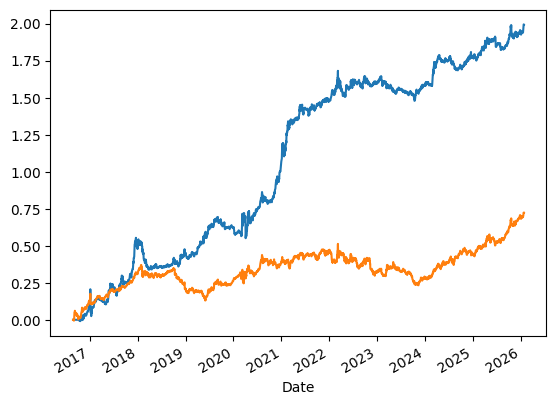

In [176]:
((pos.shift(1).rolling(5).mean().resample("W-WED").last().reindex(index = rets.index).ffill() * rets).sum(axis = 1)).cumsum().plot()
((pos2.shift(1).resample("W-WED").last().reindex(index = rets.index).ffill() * rets).sum(axis = 1)).cumsum().plot()

<Axes: xlabel='Date'>

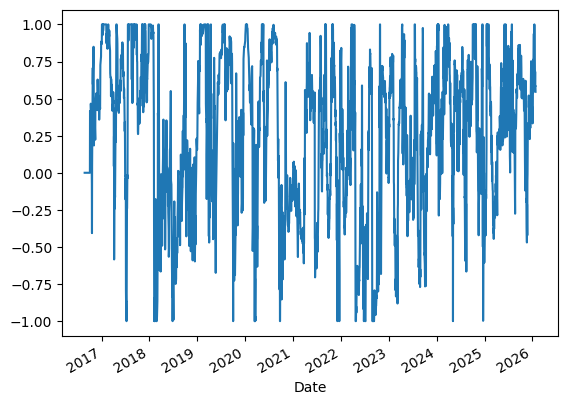

In [174]:
pos.sum(axis = 1).plot()

<Axes: xlabel='Date'>

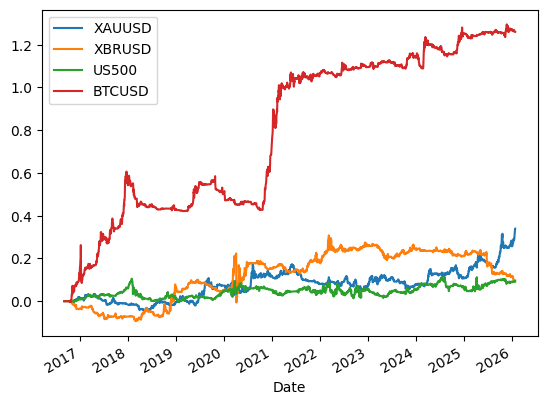

In [175]:
((pos.shift().resample('W-WED').last().reindex(index = rets.index).ffill() * rets)).cumsum().plot()